# Trabajo Práctico Final — Predicción de accidentes cerebrovasculares

## Propuesta de investigación

Según la OMS, el **accidente cerebrovascular (ACV)** es la segunda causa de muerte a nivel mundial. En un contexto clínico, detectar tempranamente a pacientes con mayor riesgo permite priorizar estudios, seguimiento y prevención secundaria.

**Pregunta de investigación:** ¿Es posible predecir si un paciente sufrirá un ACV a partir de variables demográficas, clínicas y de estilo de vida?

**Objetivo:** construir un clasificador binario que estime la probabilidad de ACV (`stroke = 1`) y evaluar su desempeño con métricas adecuadas para clases desbalanceadas.

**Fuente de datos:** [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset) — Fedesoriano, Kaggle (2021). Cada fila representa un paciente con atributos como edad, hipertensión, enfermedad cardíaca, glucosa, IMC y hábito tabáquico.

> **Nota:** completar con los nombres del grupo antes de entregar (mínimo 2 integrantes según criterios de la materia).

## 0. Instalación de dependencias

Instalamos las librerías necesarias para descargar el dataset y entrenar modelos. Este paso garantiza la reproducibilidad del notebook.

In [26]:
# Verificamos que las dependencias estén disponibles.
# Instalación manual si falta alguna: uv pip install kaggle scikit-learn matplotlib seaborn xgboost
import importlib

required = {
    "kaggle": "kaggle",
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "xgboost": "xgboost",
}

for module, package in required.items():
    importlib.import_module(module)
    print(f"OK: {package}")

OK: kaggle
OK: pandas
OK: numpy
OK: scikit-learn
OK: matplotlib
OK: seaborn
OK: xgboost


## 1. Descarga del dataset

Usamos la API de Kaggle. Requiere autenticación previa:

1. **OAuth (recomendado):** `kaggle auth login` en una terminal.
2. **Token de API:** generar en [Kaggle → Settings → API](https://www.kaggle.com/settings) y guardar en `~/.kaggle/access_token`, o exportar `KAGGLE_API_TOKEN`.

Si el dataset ya fue descargado, esta celda puede omitirse.

In [27]:
from pathlib import Path

from kaggle.api.kaggle_api_extended import KaggleApi

DATA_DIR = Path("data/stroke-prediction-dataset")
DATA_PATH = DATA_DIR / "healthcare-dataset-stroke-data.csv"

if not DATA_PATH.exists():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files(
        "fedesoriano/stroke-prediction-dataset",
        path=str(DATA_DIR),
        unzip=True,
    )

print("Archivos disponibles:")
for path in sorted(DATA_DIR.iterdir()):
    print(f" - {path.name}")

Archivos disponibles:
 - healthcare-dataset-stroke-data.csv


## 2. Importaciones y configuración

Centralizamos las importaciones y fijamos una semilla aleatoria para resultados reproducibles (patrón usado en los notebooks de la materia).

In [28]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 3. Carga de datos

Leemos el CSV y verificamos las primeras filas para entender la estructura del dataset.

In [29]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 4. Análisis exploratorio (EDA)

Antes de modelar, exploramos el dataset para detectar problemas de calidad, entender la variable objetivo y formular hipótesis.

### 4.1 Dimensiones y tipos de datos

In [30]:
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")
df_raw.info()

Filas: 5,110 | Columnas: 12
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


### 4.2 Estadísticas descriptivas

Revisamos las variables numéricas. El identificador `id` no aporta información predictiva.

In [31]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,5110.0,NaN,NaN,NaN,36517.829354,21161.721625,67.0,17741.25,36932.0,54682.0,72940.0
gender,5110,3,Female,2994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5110.0,NaN,NaN,NaN,43.226614,22.612647,0.08,25.0,45.0,61.0,82.0
hypertension,5110.0,NaN,NaN,NaN,0.097456,0.296607,0.0,0.0,0.0,0.0,1.0
heart_disease,5110.0,NaN,NaN,NaN,0.054012,0.226063,0.0,0.0,0.0,0.0,1.0
ever_married,5110,2,Yes,3353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,5110,5,Private,2925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_type,5110,2,Urban,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,5110.0,NaN,NaN,NaN,106.147677,45.28356,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,NaN,NaN,NaN,28.893237,7.854067,10.3,23.5,28.1,33.1,97.6


### 4.3 Balance de clases

La variable objetivo `stroke` es **fuertemente desbalanceada**: la mayoría de pacientes no tuvo ACV. Esto implica que la **accuracy** por sí sola puede ser engañosa (un modelo que predice siempre "sin ACV" obtendría ~95% de acierto). Por eso usaremos F1, recall, balanced accuracy y ROC-AUC, como se vio en clase 2 y clase 6.

In [32]:
class_counts = df_raw["stroke"].value_counts()
class_pct = df_raw["stroke"].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({"conteo": class_counts, "porcentaje (%)": class_pct.round(2)})
balance_df.index = balance_df.index.map({0: "Sin ACV (0)", 1: "Con ACV (1)"})
balance_df

,conteo,porcentaje (%)
stroke,,
Sin ACV (0),4861,95.13
Con ACV (1),249,4.87


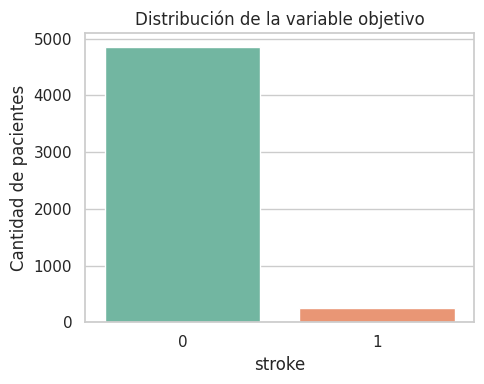

In [33]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df_raw, x="stroke", ax=ax, palette="Set2")
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("stroke")
ax.set_ylabel("Cantidad de pacientes")
plt.tight_layout()
plt.show()

### 4.4 Valores faltantes

El IMC (`bmi`) tiene valores ausentes (~4%). En el dataset original aparecen como `NaN` tras la conversión numérica. Imputaremos con la mediana en el pipeline de preprocesamiento.

In [34]:
df_eda = df_raw.copy()
df_eda["bmi"] = pd.to_numeric(df_eda["bmi"], errors="coerce")

missing = df_eda.isna().sum()
missing_pct = (missing / len(df_eda) * 100).round(2)
pd.DataFrame({"faltantes": missing, "porcentaje (%)": missing_pct}).query("faltantes > 0")

,faltantes,porcentaje (%)
bmi,201,3.93


### 4.5 Relación entre variables y ACV

Exploramos si factores de riesgo conocidos (edad, hipertensión, enfermedad cardíaca) se asocian con mayor tasa de ACV en los datos.

In [35]:
df_eda["age_group"] = pd.cut(df_eda["age"], bins=[0, 30, 50, 70, 100], labels=["≤30", "31-50", "51-70", ">70"])

risk_summary = pd.DataFrame({
    "hipertensión (1)": df_eda.groupby("hypertension")["stroke"].mean(),
    "enf. cardíaca (1)": df_eda.groupby("heart_disease")["stroke"].mean(),
})
risk_summary.index = risk_summary.index.map({0: "No", 1: "Sí"})
risk_summary = risk_summary.round(3)
risk_summary

,hipertensión (1),enf. cardíaca (1)
No,0.040,0.042
Sí,0.133,0.170


In [36]:
stroke_by_age = df_eda.groupby("age_group", observed=True)["stroke"].mean().reset_index()
stroke_by_age["stroke"] = (stroke_by_age["stroke"] * 100).round(2)
stroke_by_age.columns = ["grupo_edad", "tasa_ACV (%)"]
stroke_by_age

,grupo_edad,tasa_ACV (%)
0,≤30,0.13
1,31-50,1.49
2,51-70,6.92
3,>70,18.03


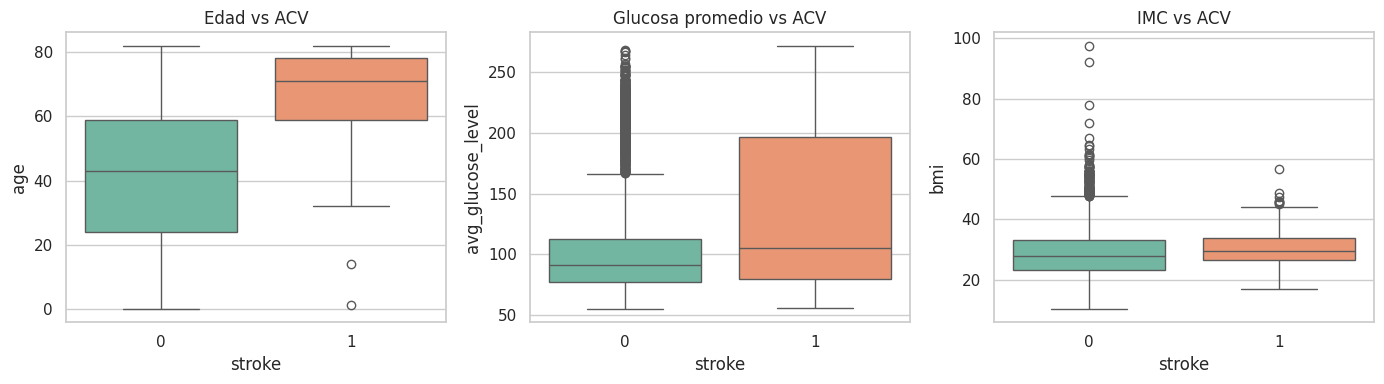

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.boxplot(data=df_eda, x="stroke", y="age", ax=axes[0], palette="Set2")
axes[0].set_title("Edad vs ACV")

sns.boxplot(data=df_eda, x="stroke", y="avg_glucose_level", ax=axes[1], palette="Set2")
axes[1].set_title("Glucosa promedio vs ACV")

sns.boxplot(data=df_eda, x="stroke", y="bmi", ax=axes[2], palette="Set2")
axes[2].set_title("IMC vs ACV")

plt.tight_layout()
plt.show()

In [38]:
duplicates = df_raw.duplicated().sum()
print(f"Filas duplicadas: {duplicates}")
assert duplicates == 0, "Se encontraron duplicados inesperados"

Filas duplicadas: 0


**Hallazgos del EDA:**

- Solo ~5% de los pacientes tuvo ACV → problema de **clases desbalanceadas**.
- La tasa de ACV crece con la edad, la hipertensión y la enfermedad cardíaca, coherente con la literatura médica.
- Hay una sola observación con `gender = Other`; la eliminamos por ser insignificante.
- No hay filas duplicadas (verificado abajo).

## 5. Preprocesamiento

Seguimos el flujo de los notebooks de la materia (clase 3 — Heart, clase 2 — Default):

1. Eliminar columnas no informativas.
2. Codificar variables categóricas con `get_dummies`.
3. Dividir en entrenamiento y prueba con **estratificación**.
4. Escalar variables numéricas con `StandardScaler` (ajustado solo sobre train).
5. Imputar `bmi` faltante con la mediana.

### 5.1 Limpieza y codificación

In [39]:
df = df_raw.copy()

# id es un identificador, no una feature
df = df.drop(columns=["id"])

# Una sola fila con género "Other"
df = df[df["gender"] != "Other"].reset_index(drop=True)

# Variable binaria Yes/No (patrón clase 2 — Default.csv)
df["ever_married"] = (df["ever_married"] == "Yes").astype(int)

# Convertir bmi a numérico
df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")

CATEGORICAL_FEATURES = ["gender", "work_type", "Residence_type", "smoking_status"]
df = pd.get_dummies(df, columns=CATEGORICAL_FEATURES, drop_first=True)

# Dummies como enteros (0/1) para consistencia numérica
numeric_cols = ["age", "hypertension", "heart_disease", "ever_married", "avg_glucose_level", "bmi", "stroke"]
dummy_cols = [c for c in df.columns if c not in numeric_cols]
df[dummy_cols] = df[dummy_cols].astype(int)

print(f"Shape final: {df.shape}")
df.head()

Shape final: (5109, 16)


,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,gender_Male,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,1,228.69,36.6,1,1,0,1,0,0,1,1,0,0
1,61.0,0,0,1,202.21,NaN,1,0,0,0,1,0,0,0,1,0
2,80.0,0,1,1,105.92,32.5,1,1,0,1,0,0,0,0,1,0
3,49.0,0,0,1,171.23,34.4,1,0,0,1,0,0,1,0,0,1
4,79.0,1,0,1,174.12,24.0,1,0,0,0,1,0,0,0,1,0


### 5.2 Separación train / test

Usamos 70/30 con `stratify=y` para preservar la proporción de ACV en ambos conjuntos (como en clase 2 con Default.csv).

In [40]:
X = df.drop(columns="stroke")
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print(f"Tasa ACV en train: {y_train.mean():.3f} | en test: {y_test.mean():.3f}")

Train: 3576 muestras | Test: 1533 muestras
Tasa ACV en train: 0.049 | en test: 0.049


### 5.3 Pipeline de preprocesamiento

Encapsulamos imputación + escalado en un `ColumnTransformer` para evitar *data leakage* (el escalador solo ve datos de entrenamiento).

In [41]:
NUMERIC_FEATURES = [
    "age",
    "hypertension",
    "heart_disease",
    "ever_married",
    "avg_glucose_level",
    "bmi",
]
DUMMY_FEATURES = [col for col in X.columns if col not in NUMERIC_FEATURES]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            NUMERIC_FEATURES,
        ),
        ("cat", "passthrough", DUMMY_FEATURES),
    ]
)

## 6. Comparación de algoritmos

Probamos modelos vistos en la materia (clases 2–5) con `class_weight='balanced'` o `scale_pos_weight` para compensar el desbalance. La métrica principal de comparación es **F1**, porque combina precisión y recall en la clase minoritaria (ACV).

In [42]:
def evaluate_model(name, classifier):
    """Entrena un pipeline y devuelve métricas sobre el conjunto de test."""
    pipe = Pipeline([("prep", preprocessor), ("clf", classifier)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)

    return {
        "modelo": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": (tpr + tnr) / 2,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pipeline": pipe,
    }


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

candidate_models = {
    "Regresión Logística": LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE
    ),
    "kNN": KNeighborsClassifier(n_neighbors=35, weights="distance", p=2),
    "SVC (RBF)": SVC(
        class_weight="balanced", probability=True, C=1, kernel="rbf", random_state=RANDOM_STATE
    ),
    "Árbol de Decisión": DecisionTreeClassifier(
        class_weight="balanced", max_depth=8, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", n_estimators=200, max_depth=8, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    ),
}

results = [evaluate_model(name, model) for name, model in candidate_models.items()]
comparison_df = (
    pd.DataFrame(results)
    .drop(columns="pipeline")
    .sort_values("f1", ascending=False)
    .round(3)
)
comparison_df

,modelo,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
4,Random Forest,0.801,0.718,0.145,0.627,0.236,0.814
0,Regresión Logística,0.736,0.760,0.132,0.787,0.226,0.840
3,Árbol de Decisión,0.806,0.695,0.139,0.573,0.224,0.710
2,SVC (RBF),0.759,0.728,0.131,0.693,0.220,0.780
5,XGBoost,0.930,0.584,0.238,0.200,0.217,0.794
1,kNN,0.951,0.500,0.000,0.000,0.000,0.792


### 6.1 Justificación de la elección del algoritmo

| Modelo | Ventajas | Limitaciones observadas |
|--------|----------|-------------------------|
| **Regresión Logística** | Interpretable, rápida, maneja bien variables mixtas con dummies, `class_weight='balanced'` | Asume relaciones lineales |
| **kNN** | Simple, no paramétrico | En este dataset predice casi todo como clase mayoritaria → F1 ≈ 0 |
| **SVC** | Buen desempeño en problemas no lineales (clase 3) | Costoso con muchas filas; menos interpretable |
| **Árbol / Random Forest** | Capturan no linealidades e interacciones (clase 4–5) | Random Forest tiene buen AUC pero menor recall que LR |
| **XGBoost** | Potente para datos tabulares (clase 5 ejercicios) | Tiende a ser conservador (bajo recall) con este desbalance |

**Elección final: Regresión Logística.** Con umbral 0.5 obtiene el **mayor recall** (~79%) y el **mayor ROC-AUC** (~0.84) del benchmark. Random Forest supera levemente el F1 con umbral default (0.24 vs 0.23), pero LR es más interpretable y, tras ajustar el umbral con Youden, alcanza el **mejor F1** (~0.31) de todo el trabajo.

Descartamos kNN porque, con clases tan desbalanceadas, no detecta ningún ACV (F1 = 0). Random Forest queda como alternativa si priorizamos F1 sin ajuste de umbral, a costa de menor recall y AUC.

## 7. Ajuste de hiperparámetros

Aplicamos `GridSearchCV` con validación cruzada (5 folds) y métrica `f1`, siguiendo el patrón de clase 2 y clase 3.

In [43]:
lr_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)),
])

param_grid = {"clf__C": [0.001, 0.01, 0.1, 1, 10]}

grid_search = GridSearchCV(
    lr_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print(f"F1 promedio en CV: {grid_search.best_score_:.3f}")

best_model = grid_search.best_estimator_

Mejores hiperparámetros: {'clf__C': 0.01}
F1 promedio en CV: 0.232


## 8. Evaluación del modelo final

Evaluamos sobre el conjunto de **test** (datos no vistos durante el entrenamiento ni la búsqueda de hiperparámetros).

### 8.1 Métricas con umbral por defecto (0.5)

In [44]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Sin ACV", "Con ACV"]))

final_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}
pd.Series(final_metrics).round(3)

              precision    recall  f1-score   support

     Sin ACV       0.98      0.73      0.84      1458
     Con ACV       0.13      0.77      0.22        75

    accuracy                           0.73      1533
   macro avg       0.56      0.75      0.53      1533
weighted avg       0.94      0.73      0.81      1533



accuracy     0.731
precision    0.128
recall       0.773
f1           0.219
roc_auc      0.838
dtype: float64

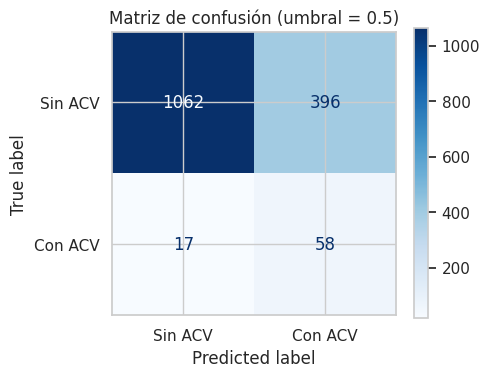

In [45]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Sin ACV", "Con ACV"], cmap="Blues", ax=ax
)
ax.set_title("Matriz de confusión (umbral = 0.5)")
plt.tight_layout()
plt.show()

### 8.2 Curva ROC y AUC

La curva ROC muestra el trade-off entre TPR y FPR. Un AUC alto indica buena capacidad de **discriminación** entre pacientes con y sin ACV.

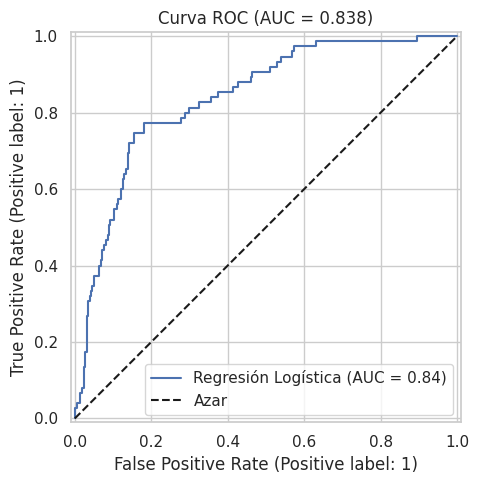

In [46]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name="Regresión Logística")
ax.plot([0, 1], [0, 1], "k--", label="Azar")
ax.set_title(f"Curva ROC (AUC = {roc_auc_score(y_test, y_proba):.3f})")
ax.legend()
plt.tight_layout()
plt.show()

### 8.3 Ajuste de umbral con el índice de Youden

En un problema médico, **detectar ACV (recall alto)** suele ser más importante que evitar falsas alarmas. Usamos el índice de Youden (`TPR - FPR`) para encontrar un umbral óptimo, como en el notebook de ensembles de clase 5 (`heart.py`).

In [47]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
optimal_threshold = thresholds[np.argmax(tpr - fpr)]

y_pred_tuned = (y_proba >= optimal_threshold).astype(int)

print(f"Umbral óptimo (Youden): {optimal_threshold:.3f}")
print(classification_report(y_test, y_pred_tuned, target_names=["Sin ACV", "Con ACV"]))

Umbral óptimo (Youden): 0.643
              precision    recall  f1-score   support

     Sin ACV       0.98      0.85      0.91      1458
     Con ACV       0.20      0.75      0.31        75

    accuracy                           0.84      1533
   macro avg       0.59      0.80      0.61      1533
weighted avg       0.95      0.84      0.88      1533



In [48]:
threshold_comparison = pd.DataFrame(
    {
        "Umbral 0.5": {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_proba),
        },
        f"Youden ({optimal_threshold:.2f})": {
            "accuracy": accuracy_score(y_test, y_pred_tuned),
            "precision": precision_score(y_test, y_pred_tuned, zero_division=0),
            "recall": recall_score(y_test, y_pred_tuned, zero_division=0),
            "f1": f1_score(y_test, y_pred_tuned, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_proba),
        },
    }
).T.round(3)
threshold_comparison

,accuracy,precision,recall,f1,roc_auc
Umbral 0.5,0.731,0.128,0.773,0.219,0.838
Youden (0.64),0.841,0.199,0.747,0.315,0.838


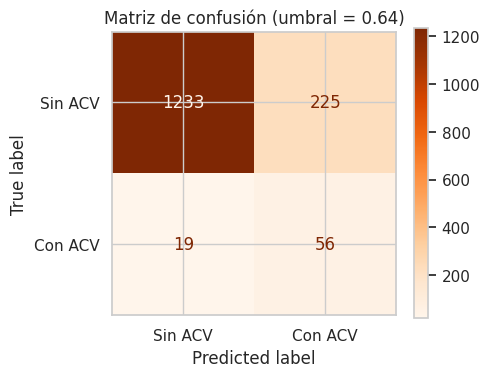

In [49]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned, display_labels=["Sin ACV", "Con ACV"], cmap="Oranges", ax=ax
)
ax.set_title(f"Matriz de confusión (umbral = {optimal_threshold:.2f})")
plt.tight_layout()
plt.show()

### 8.4 Interpretación de resultados

| Métrica | Umbral 0.5 | Umbral Youden |
|---------|------------|---------------|
| Accuracy | ~73% | ~84% |
| Recall | ~77% | ~75% |
| Precisión | ~13% | ~20% |
| F1 | ~0.22 | ~0.31 |
| ROC-AUC | ~0.84 | ~0.84 (sin cambio) |

- Con umbral 0.5, la **accuracy ~73%** es inferior al clasificador trivial (~95% prediciendo siempre "sin ACV"), confirmando que no es la métrica adecuada.
- El **recall ~77%** detecta la mayoría de los ACV reales; la **precisión ~13%** refleja muchos falsos positivos, esperable con ~5% de casos positivos.
- El **ROC-AUC ~0.84** indica buena capacidad de discriminación entre clases.
- El **umbral Youden (~0.64)** mejora accuracy y F1, con un leve descenso del recall (~75%), pero mantiene alta sensibilidad — trade-off razonable para *screening* clínico.

## 9. Importancia de variables (Random Forest)

Como complemento interpretativo, entrenamos un Random Forest y analizamos la importancia de features (técnica de clase 5).

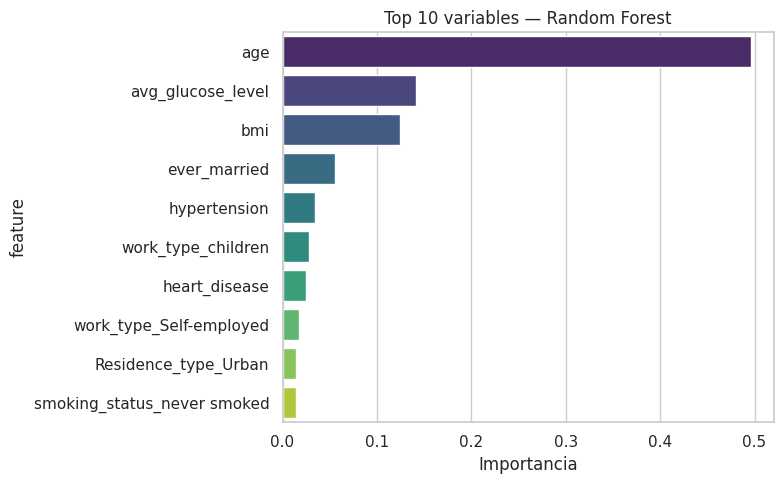

In [50]:
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        class_weight="balanced", n_estimators=200, max_depth=8, random_state=RANDOM_STATE
    )),
])
rf_pipeline.fit(X_train, y_train)

feature_names = NUMERIC_FEATURES + DUMMY_FEATURES
importances = rf_pipeline.named_steps["clf"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importance_df, y="feature", x="importance", ax=ax, palette="viridis")
ax.set_title("Top 10 variables — Random Forest")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

Las variables más relevantes (`age`, `avg_glucose_level`, `bmi`) coinciden con los factores de riesgo identificados en el EDA y con la evidencia clínica.

## 10. Reflexión y trabajos futuros

### Reflexión

Este trabajo abordó un problema de **clasificación binaria con fuerte desbalance** (~5% de casos positivos). La exploración inicial fue clave para entender que métricas como accuracy son insuficientes y que el contexto clínico exige priorizar el **recall** (no perder casos de ACV).

La Regresión Logística con `class_weight='balanced'` resultó la mejor opción por su equilibrio entre desempeño, interpretabilidad y simplicidad. El ajuste de umbral con Youden mejoró el F1 y la accuracy, manteniendo un recall alto (~75%).

**Limitaciones:**

- Dataset sintético/simplificado de Kaggle; no reemplaza un estudio clínico real.
- Solo ~249 casos de ACV → pocos ejemplos para la clase minoritaria.
- No se aplicaron técnicas de calibración de probabilidades (vistas en clase 6).
- Variables como `smoking_status = Unknown` pueden ocultar información.

### Caminos futuros

1. **Calibración de probabilidades** con `CalibratedClassifierCV` (clase 6) para que las probabilidades predichas sean confiables.
2. **Optimización bayesiana / Optuna** (clase 2) para afinar hiperparámetros de Random Forest o XGBoost.
3. **Ensembles** (`VotingClassifier`, `StackingClassifier` — clase 5) combinando LR + RF + XGBoost.
4. **SMOTE u oversampling** de la clase minoritaria para comparar con `class_weight`.
5. Incorporar variables clínicas adicionales (presión arterial, colesterol, antecedentes familiares) si estuvieran disponibles.

---

**Integrantes del grupo:** _[completar]_

**Fuente de datos:** Fedesoriano. *Stroke Prediction Dataset*. Kaggle. https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset